In [23]:
import os
import sys
import copy
import pandas as pd
import numpy as np
import yfinance as yf

# get the absolute path of the current file
current_dir = os.path.dirname(os.path.abspath("__file__"))
# get the project root (one level up from notebooks/)
project_root = os.path.abspath(os.path.join(current_dir, ".."))
# add project root to sys.path
if project_root not in sys.path:
    sys.path.append(project_root)

In [53]:
%reload_ext autoreload
%autoreload 2

from utils.stock_utils import download_stock_data
from utils.kpi import CAGR, volatility, Sharpe, max_dd, Sortino, calamar, jensens_alpha

List of all the stocks I want to have in my tradable universe for backtesting

In [5]:
nifty_top_20 = [
    "RELIANCE.NS", "HDFCBANK.NS", "ICICIBANK.NS", "INFY.NS", "AXISBANK.NS", 
    "TCS.NS", "LT.NS", "BHARTIARTL.NS", "SBIN.NS", "ITC.NS", 
    "HINDUNILVR.NS", "BAJFINANCE.NS", "KOTAKBANK.NS", "MARUTI.NS", "M&M.NS", 
    "TATASTEEL.NS", "SUNPHARMA.NS", "HCLTECH.NS", "ADANIENT.NS", "NTPC.NS"
]

# PORTFOLIO REBALANCING

In [8]:
ohlcv_data = download_stock_data(nifty_top_20, 3650, "1mo")

YF.download() has changed argument auto_adjust default to True
Successfully downloaded 20/20 stocks.


In [31]:
ohlcv_data

{'RELIANCE.NS': Price              Open         High          Low        Close     Volume
 Date                                                                     
 2016-04-01   227.691317   234.440321   214.489117   215.332748  349334205
 2016-05-01   214.522006   218.017031   202.831759   209.887543  298363064
 2016-06-01   209.909460   217.841742   204.529982   212.363647  261190948
 2016-07-01   213.152475   227.614629   212.549874   222.388535  232305291
 2016-08-01   223.067834   235.338757   215.486154   232.271027  270476979
 ...                 ...          ...          ...          ...        ...
 2025-11-01  1486.000000  1581.300049  1470.099976  1567.500000  201185705
 2025-12-01  1575.000000  1580.900024  1517.599976  1570.400024  183581032
 2026-01-01  1573.699951  1611.800049  1368.000000  1395.400024  279063270
 2026-02-01  1396.000000  1489.500000  1335.000000  1393.900024  226233605
 2026-03-01  1375.500000  1434.000000  1307.000000  1380.699951  221751792
 
 [120 ro

In [15]:
def get_monthly_return(ohlcv_data):
    """
    Calculate monthly returns for the given stocks.
    
    Parameters:
    mid_cap_dict (dictionary): Dictionary of stock symbols.
    
    Returns:
    pd.DataFrame: DataFrame containing monthly returns for each stock.
    """
    ohlcv_dict = copy.deepcopy(ohlcv_data)
    return_df = pd.DataFrame()
    for stock in nifty_top_20:
        print("calculated monthly return for ", stock)
        ohlcv_dict[stock]["mon_ret"] = ohlcv_dict[stock]["Close"].pct_change()
        return_df[stock] = ohlcv_dict[stock]["mon_ret"]
    return_df.dropna(inplace=True)
    return return_df

In [16]:
return_df = get_monthly_return(ohlcv_data)

calculated monthly return for  RELIANCE.NS
calculated monthly return for  HDFCBANK.NS
calculated monthly return for  ICICIBANK.NS
calculated monthly return for  INFY.NS
calculated monthly return for  AXISBANK.NS
calculated monthly return for  TCS.NS
calculated monthly return for  LT.NS
calculated monthly return for  BHARTIARTL.NS
calculated monthly return for  SBIN.NS
calculated monthly return for  ITC.NS
calculated monthly return for  HINDUNILVR.NS
calculated monthly return for  BAJFINANCE.NS
calculated monthly return for  KOTAKBANK.NS
calculated monthly return for  MARUTI.NS
calculated monthly return for  M&M.NS
calculated monthly return for  TATASTEEL.NS
calculated monthly return for  SUNPHARMA.NS
calculated monthly return for  HCLTECH.NS
calculated monthly return for  ADANIENT.NS
calculated monthly return for  NTPC.NS


In [17]:
def portfolio_rebalance(return_df, keep, throw):
    """
    Rebalance the portfolio based on monthly returns.
    
    Parameters:
    return_df (pd.DataFrame): DataFrame containing monthly returns for each stock.
    keep (int): Number of stocks to keep in the portfolio.
    throw (int): Number of stocks to throw out of the portfolio.
    initial_investment (float): Initial investment amount (default is 1,000,000).
    
    Returns:
    pd.DataFrame: DataFrame containing portfolio value over time.
    """
    df = return_df.copy()
    portfolio = []
    monthly_return = []
    for i in range (len(df)):
        if len(portfolio) > 0:
            monthly_return.append(df[portfolio].iloc[i, :].mean())
            bad_stocks = df[portfolio].iloc[i,:].sort_values(ascending=True)[:throw].index.values.tolist()
            portfolio = [t for t in portfolio if t not in bad_stocks]
        else:
            monthly_return.append(0)
            print("No stocks in portfolio")
        fill = keep - len(portfolio)
        new_picks = df.iloc[i,:].sort_values(ascending=False)[:fill].index.values.tolist()
        portfolio = portfolio + new_picks
        print(portfolio)
    monthly_ret_df = pd.DataFrame(np.array(monthly_return),columns=["mon_ret"])
    return monthly_ret_df

In [25]:
new_portfolio = portfolio_rebalance(return_df, 6, 3)

No stocks in portfolio
['LT.NS', 'BAJFINANCE.NS', 'MARUTI.NS', 'AXISBANK.NS', 'SBIN.NS', 'ITC.NS']
['BAJFINANCE.NS', 'SBIN.NS', 'ITC.NS', 'ADANIENT.NS', 'NTPC.NS', 'M&M.NS']
['BAJFINANCE.NS', 'SBIN.NS', 'ITC.NS', 'BAJFINANCE.NS', 'MARUTI.NS', 'ICICIBANK.NS']
['BAJFINANCE.NS', 'SBIN.NS', 'BAJFINANCE.NS', 'AXISBANK.NS', 'SBIN.NS', 'TATASTEEL.NS']
['SBIN.NS', 'SBIN.NS', 'TATASTEEL.NS', 'MARUTI.NS', 'HCLTECH.NS', 'RELIANCE.NS']
['TATASTEEL.NS', 'MARUTI.NS', 'ICICIBANK.NS', 'TATASTEEL.NS', 'MARUTI.NS', 'KOTAKBANK.NS']
['TATASTEEL.NS', 'ICICIBANK.NS', 'TATASTEEL.NS', 'NTPC.NS', 'HCLTECH.NS', 'TATASTEEL.NS']
['ICICIBANK.NS', 'NTPC.NS', 'HCLTECH.NS', 'ADANIENT.NS', 'RELIANCE.NS', 'ITC.NS']
['ICICIBANK.NS', 'ADANIENT.NS', 'ITC.NS', 'BAJFINANCE.NS', 'TATASTEEL.NS', 'BHARTIARTL.NS']
['ADANIENT.NS', 'BAJFINANCE.NS', 'BHARTIARTL.NS', 'RELIANCE.NS', 'ADANIENT.NS', 'TCS.NS']
['ADANIENT.NS', 'RELIANCE.NS', 'ADANIENT.NS', 'ADANIENT.NS', 'SBIN.NS', 'KOTAKBANK.NS']
['RELIANCE.NS', 'KOTAKBANK.NS', 'LT.NS'

In [26]:
cagr = CAGR(new_portfolio, 12, "mon_ret", False)  # Calculate CAGR
vol = volatility(new_portfolio, 12, "mon_ret", False)  # Calculate Volatility
sharpe = Sharpe(new_portfolio, 12, "mon_ret", False)  # Calculate Sharpe Ratio
mdd = max_dd(new_portfolio, "mon_ret", False) # Calculate max drawdown

# 4. Display Results
print(f"--- Statistics for your portfolio (Last 10 Years) ---")
print(f"CAGR:           {cagr:.2%}")
print(f"volatility:     {vol:.2%}")
print(f"Sharpe Ratio:   {sharpe:.2f}")
print(f"Max Drawdown:   {mdd:.2%}")


--- Statistics for your portfolio (Last 10 Years) ---
CAGR:           19.18%
volatility:     18.83%
Sharpe Ratio:   0.86
Max Drawdown:   40.83%


In [24]:
# 1. Download Data
ticker ="^NSEI"
data = yf.download(ticker, period="10y", interval="1mo")

# 2. Clean Data (yfinance multi-index handling if necessary)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# 3. Calculate KPIs
# Since we are using daily data, timeframe = 252
# Since we downloaded ohlcv, is_price = True
cagr_val = CAGR(data, timeframe=12, column='Close', is_price=True)
vol_val = volatility(data, timeframe=12, column='Close', is_price=True)
sharpe_val = Sharpe(data, timeframe=12, column='Close', is_price=True)
mdd_val = max_dd(data, column='Close', is_price=True)

# 4. Display Results
print(f"--- Statistics for {ticker} (Last 10 Years) ---")
print(f"CAGR:           {cagr_val:.2%}")
print(f"volatility:     {vol_val:.2%}")
print(f"Sharpe Ratio:   {sharpe_val:.2f}")
print(f"Max Drawdown:   {mdd_val:.2%}")

[*********************100%***********************]  1 of 1 completed

--- Statistics for ^NSEI (Last 10 Years) ---
CAGR:           11.42%
volatility:     15.89%
Sharpe Ratio:   0.53
Max Drawdown:   29.34%


/Users/harshergill/Documents/projects/quant/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


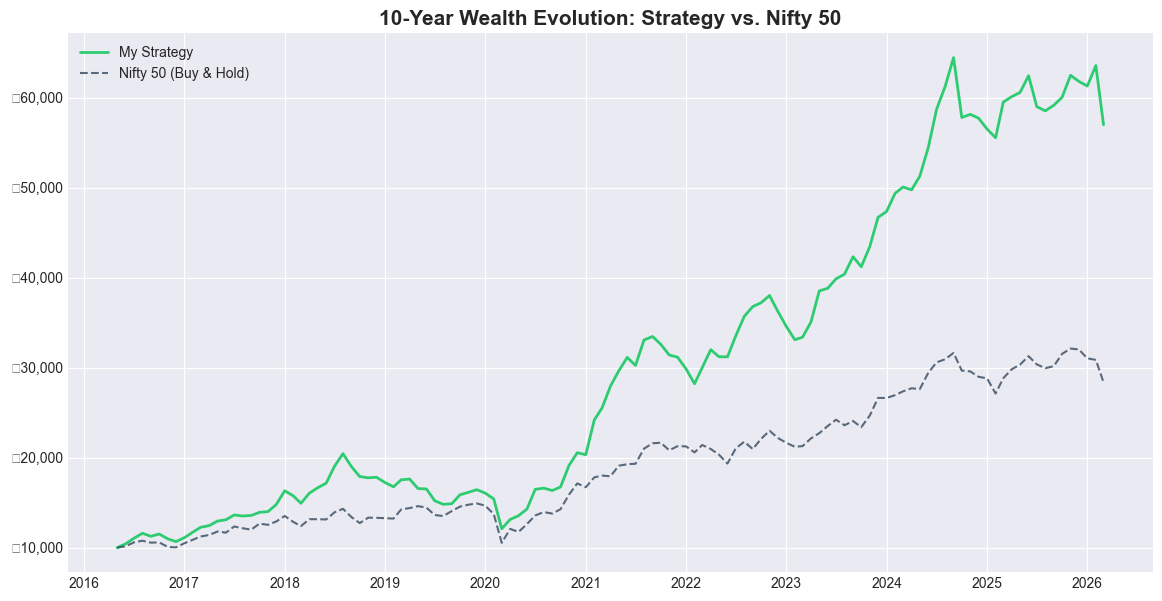

In [ ]:
# 1. Align the Index by taking only the dates that have matching portfolio values
# Using [-len(new_portfolio):] ensures we grab the most recent months
portfolio_series = pd.Series(new_portfolio["mon_ret"].values, index=data.index[-len(new_portfolio):])

# 2. Slice the Nifty data to match the same for a fair comparison
nifty_slice = data.iloc[-len(new_portfolio):].copy()
nifty_ret = nifty_slice['Close'].pct_change().fillna(0) # First month of the slice becomes 0

# 3. Setup Wealth Calculation
initial_investment = 10000
portfolio_value = (1 + portfolio_series).cumprod() * initial_investment
nifty_value = (1 + nifty_ret).cumprod() * initial_investment

# 4. Plotting 
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(portfolio_value.index, portfolio_value, label='My Strategy', color='#2ecc71', linewidth=2)
ax.plot(nifty_value.index, nifty_value, label='Nifty 50 (Buy & Hold)', color='#34495e', linestyle='--', alpha=0.8)

ax.set_title('10-Year Wealth Evolution: Strategy vs. Nifty 50', fontsize=15, fontweight='bold')
ax.yaxis.set_major_formatter(StrMethodFormatter('₹{x:,.0f}'))
plt.legend(loc='upper left')
plt.show()

In [51]:
new_portfolio

,mon_ret
0,0.000000
1,0.042405
2,0.059293
3,0.049871
4,-0.028966
...,...
114,0.040736
115,-0.010768
116,-0.008357
117,0.037039


In [54]:
## Risk adjusted metrics

data['nifty_ret'] = data['Close'].pct_change().fillna(0)

beta, alpha, portfolio_ret, benchmark_ret, ann_port_ret, ann_bench_ret = jensens_alpha(new_portfolio['mon_ret'], data['nifty_ret'], 10)

print(f"--- Risk-Adjusted Metrics ---")
print(f"Portfolio Beta:             {beta:.2f}")
print(f"Total Strategy Ret:         {portfolio_ret:.2%}")
print(f"Total Nifty Ret:            {benchmark_ret:.2%}")
print(f"Jensen's Alpha:             {alpha:.2%}")
print(f"Annualized Nifty Ret:       {ann_bench_ret:.2%}")
print(f"Annualized Portfolio Ret:   {ann_port_ret:.2%}")


--- Risk-Adjusted Metrics ---
Portfolio Beta:             -0.04
Total Strategy Ret:         469.73%
Total Nifty Ret:            194.93%
Jensen's Alpha:             12.18%
Annualized Nifty Ret:       11.42%
Annualized Portfolio Ret:   19.01%
